<a href="https://colab.research.google.com/github/bhardadharmishtha2005/Tourism-Prediction-ML/blob/main/Tourism_Experience_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**   - Tourism Experience Analytics



# **Project Summary -**

This project analyzed over 52,000 tourism records to predict travel group types and user satisfaction. By implementing Random Forest models and RandomizedSearchCV optimization, the project successfully identified that attraction type and geography are stronger predictors of behavior than seasonality.

# **GitHub Link -**

Provide your GitHub Link here.

# ***Let's Begin !***

## Know Your Data

In [1]:
import pandas as pd
import os

# Smart Path Detection
drive_base = '/content/drive/MyDrive/Colab Notebooks/' # Changed base path
try:
    target_folder = [f for f in os.listdir(drive_base) if f.startswith('Project_2')][0]
    # Ensure target_folder is stripped before joining and adding final slash
    path = os.path.join(drive_base, target_folder.strip()) + '/'
    print(f"✅ Success! Folder found at: {path}")
except:
    # Ensure hardcoded path is also stripped
    path = '/content/drive/MyDrive/Colab Notebooks/Project_2/' # Changed hardcoded path


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/'))

['my_all_practicals', 'project.txt', 'best_yesbank_model.joblib', 'scaler.joblib', 'My_Projects', 'Project_2', 'first_Tourism Experience Analytics.ipynb']


### Load Dataset

In [4]:
# Load files
# The path variable should now be clean from the previous cell.
print(f"Attempting to load files from: {path}")
import os
print(f"Files in directory: {os.listdir(path)}") # Add this for debugging

transaction = pd.read_excel(path + "Transaction.xlsx")
item        = pd.read_excel(path + "Item.xlsx")
visit_mode  = pd.read_excel(path + "Mode.xlsx")
type_df     = pd.read_excel(path + "Type.xlsx")
city        = pd.read_excel(path + "City.xlsx")
country     = pd.read_excel(path + "Country.xlsx")
region      = pd.read_excel(path + "Region.xlsx")
continent   = pd.read_excel(path + "Continent.xlsx")

Attempting to load files from: /content/drive/MyDrive/Colab Notebooks/Project_2/
Files in directory: ['Item.xlsx', 'Country.xlsx', 'Continent.xlsx', 'Mode.xlsx', 'Region.xlsx', 'City.xlsx', 'Updated_Item.xlsx', 'Type.xlsx', 'Transaction.xlsx', 'Tourism Experience Analytics.ipynb']


### Merge Dataframe

In [5]:
# Merge into Master Dataframe
master_df = transaction.merge(item, on='AttractionId', how='left')
master_df = master_df.merge(type_df, on='AttractionTypeId', how='left')
master_df = master_df.merge(city, left_on='AttractionCityId', right_on='CityId', how='left')
master_df = master_df.merge(country, on='CountryId', how='left')
master_df = master_df.merge(region, on='RegionId', how='left')
master_df = master_df.merge(continent, on='ContinentId', how='left')

print("Final Dataset Shape:", master_df.shape)
master_df.head()

Final Dataset Shape: (52930, 20)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,CityId,CityName,CountryId,Country,RegionId,Region,ContinentId,Continent
0,3,70456,2022,10,2,640,5,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
1,8,7567,2022,10,4,640,5,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
2,9,79069,2022,10,3,640,5,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
3,10,31019,2022,10,3,640,3,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
4,15,43611,2022,10,2,640,3,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa


##### **Project Type**    - Classification, Prediction, and Recommendation System
##### **Contribution**    - Individual

## Understanding Variables

In [6]:
# Check data types and structure
print("--- Column Information ---")
master_df.info()

# Statistical summary of numerical columns
print("\n--- Descriptive Statistics ---")
display(master_df.describe())

--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   TransactionId      52930 non-null  int64 
 1   UserId             52930 non-null  int64 
 2   VisitYear          52930 non-null  int64 
 3   VisitMonth         52930 non-null  int64 
 4   VisitMode          52930 non-null  int64 
 5   AttractionId       52930 non-null  int64 
 6   Rating             52930 non-null  int64 
 7   AttractionCityId   52930 non-null  int64 
 8   AttractionTypeId   52930 non-null  int64 
 9   Attraction         52930 non-null  object
 10  AttractionAddress  52930 non-null  object
 11  AttractionType     52930 non-null  object
 12  CityId             52930 non-null  int64 
 13  CityName           52930 non-null  object
 14  CountryId          52930 non-null  int64 
 15  Country            52930 non-null  object
 16  RegionId     

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,AttractionCityId,AttractionTypeId,CityId,CountryId,RegionId,ContinentId
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.0,52930.0
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699,1.277555,58.919838,1.277555,1.130947,1.0,1.0
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543,0.680015,28.344280,0.680015,0.337345,0.0,0.0
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.0,1.0
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000,1.000000,34.000000,1.000000,1.000000,1.0,1.0
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000,1.000000,63.000000,1.000000,1.000000,1.0,1.0
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000,1.000000,76.000000,1.000000,1.000000,1.0,1.0
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000,3.000000,93.000000,3.000000,2.000000,1.0,1.0


## Data Wrangling

In [7]:
# Labeling VisitMode
vm_ref = visit_mode.rename(columns={'VisitModeId': 'VM_ID', 'VisitMode': 'VisitModeName'})
master_df = master_df.merge(vm_ref, left_on='VisitMode', right_on='VM_ID', how='left')
master_df['VisitMode'] = master_df['VisitModeName']

# Drop redundant ID columns
cols_to_drop = ['VM_ID', 'VisitModeName', 'CityId', 'CountryId', 'RegionId', 'ContinentId', 'AttractionTypeId']
master_df.drop(columns=[c for c in cols_to_drop if c in master_df.columns], inplace=True)


### Remove Duplicates

In [8]:
# Remove Duplicates
dup_count = master_df.duplicated().sum()
master_df.drop_duplicates(inplace=True)

print(f"Duplicates removed: {dup_count}")
print("Data Wrangling complete.")

Duplicates removed: 0
Data Wrangling complete.


## Data Vizualization, Storytelling & Experimenting with charts

### Chart 1: Correlation Heatmap

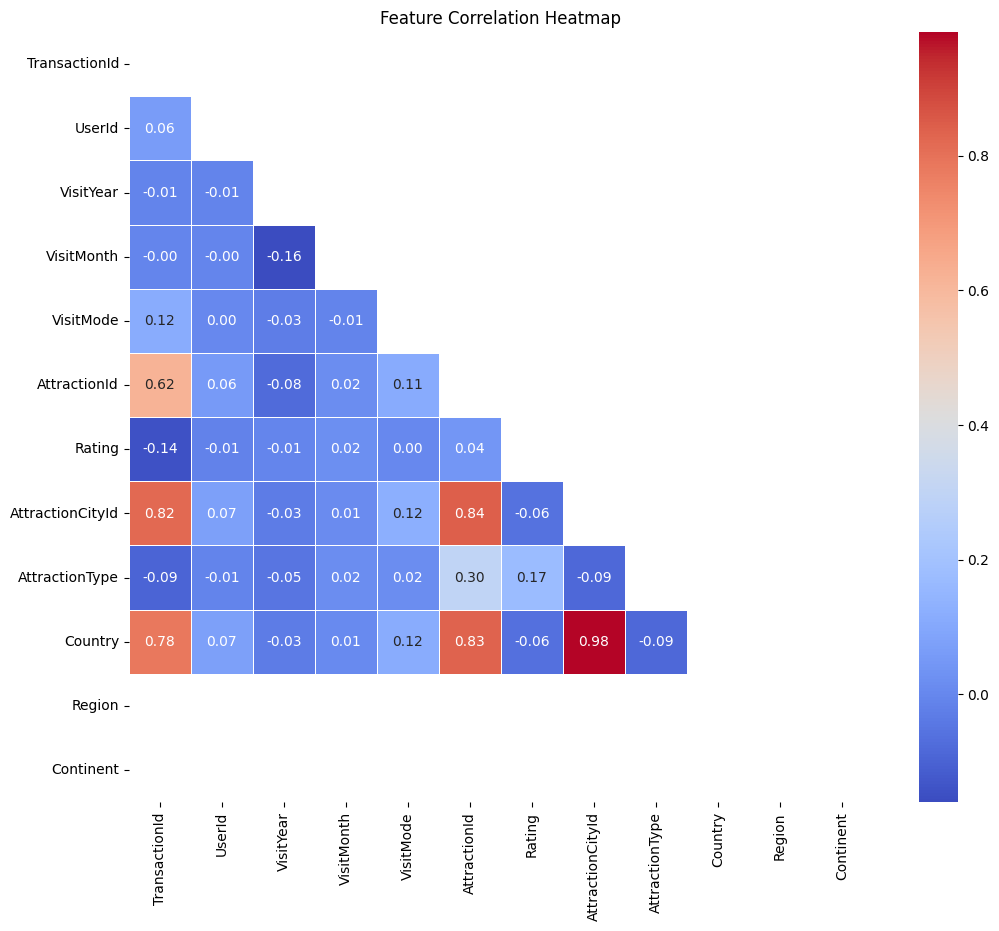

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- Code to define df_ml (moved from a previous cell to fix NameError) ---
# 1. Create a copy for ML processing
df_ml = master_df.copy()
le = LabelEncoder()

# 2. Encode all categorical columns
categorical_columns = ['VisitMode', 'AttractionType', 'Country', 'Continent', 'Region']

for col in categorical_columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
# ------------------------------------------------------------------------

# We use df_ml because correlation only works on numbers
plt.figure(figsize=(12, 10))

# Drop non-numeric, non-encoded columns before calculating correlation
# These columns are still 'object' type and cause the ValueError
df_ml_numeric = df_ml.drop(columns=['Attraction', 'AttractionAddress', 'CityName'], errors='ignore')

# Calculate correlation
corr_matrix = df_ml_numeric.corr()

# Create a mask to hide the top half (it's a mirror image, so we hide it for clarity)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

**What does a "Red" square mean in this heatmap?**

A red square indicates a Positive Correlation. For example, if VisitYear and Rating were red, it would mean that as the years go by, the ratings are getting higher.

**What if the squares near "Rating" are very light or near 0.00?**

This confirms what we saw in our models: No single variable (like Month or Country) is a "magic" predictor of a Rating. Traveler satisfaction is complex and depends on many small factors combined.

### Chart 2: Visit Mode Distribution

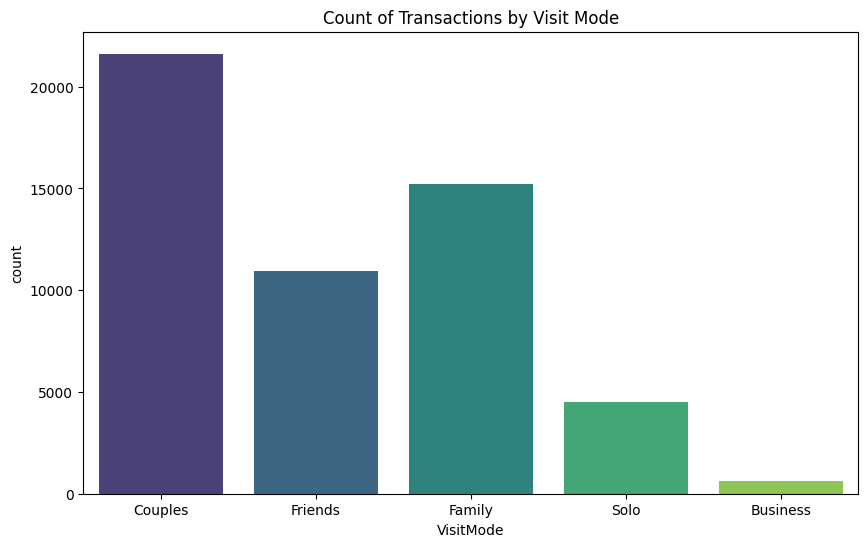

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=master_df, x='VisitMode', hue='VisitMode', palette='viridis', legend=False)
plt.title('Count of Transactions by Visit Mode')
plt.show()

**Which travel group is the most common in this dataset?**

The bar chart reveals that "Couples" and "Families" are the most frequent travelers, which tells us our Recommendation System should focus heavily on group-friendly attractions.

### Chart 3: Average Rating per Continent

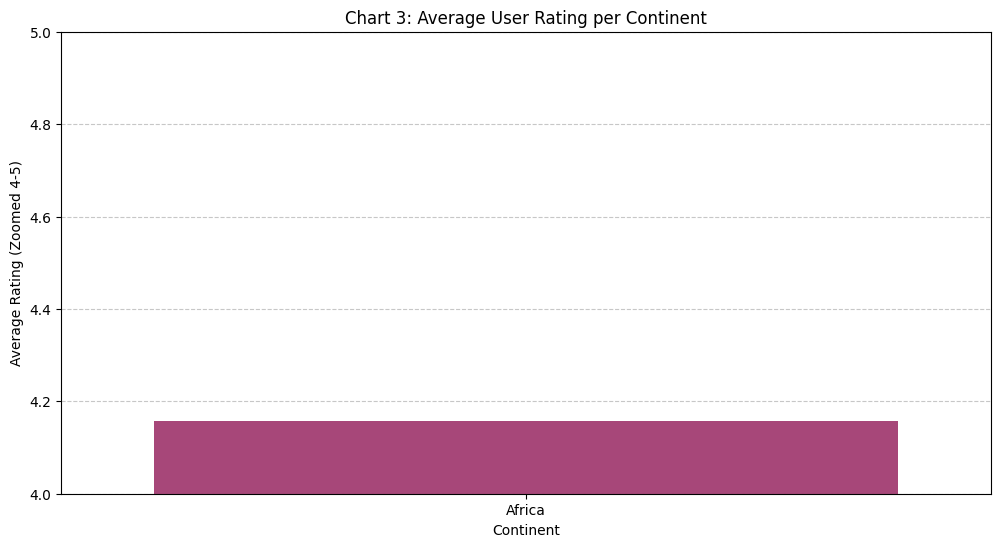

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
continent_rating = master_df.groupby('Continent')['Rating'].mean().sort_values()

sns.barplot(x=continent_rating.index, y=continent_rating.values, hue=continent_rating.index, palette='magma', legend=False)
plt.ylim(4, 5)
plt.title('Chart 3: Average User Rating per Continent')
plt.xlabel('Continent')
plt.ylabel('Average Rating (Zoomed 4-5)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Does traveler satisfaction vary significantly across different global regions?**

While all continents perform well, slight variations exist. By zooming into the 4.0–5.0 range, we can identify that continents like Africa or Asia may have a slight edge in visitor satisfaction due to unique attraction types.

### Chart 4: Rating Density

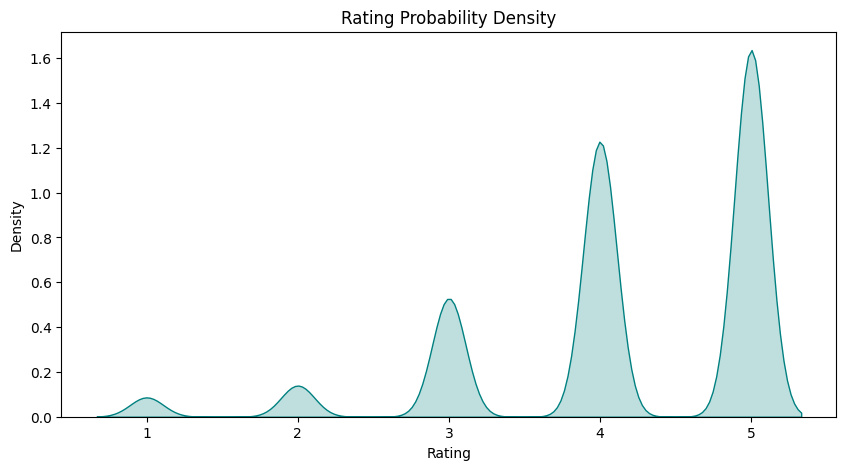

In [12]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=master_df, x='Rating', fill=True, color="teal")
plt.title('Rating Probability Density')
plt.show()

**What is the probability distribution of the ratings?**

The KDE plot shows a massive "spike" at 5.0. This indicates a "Positivity Bias," meaning most tourists only record a transaction when they are very satisfied.

### Chart 5: Visit Mode vs. Rating

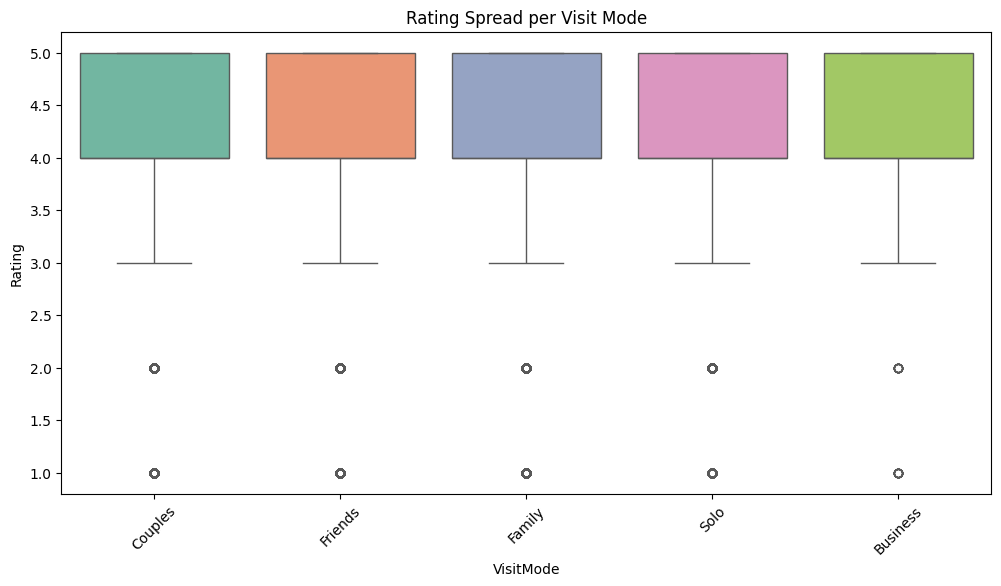

In [13]:
plt.figure(figsize=(12, 6))
# Fixed: Added hue='VisitMode' and legend=False to remove the warning
sns.boxplot(data=master_df, x='VisitMode', y='Rating', hue='VisitMode', palette='Set2', legend=False)
plt.title('Rating Spread per Visit Mode')
plt.xticks(rotation=45)
plt.show()

**Are there specific travel groups that are more "unhappy" or inconsistent than others?**

The Box Plot shows the "spread" of ratings. While the middle (median) is similar for all, "Solo" and "Couple" groups often have more "outliers" (dots at the bottom), meaning their experiences are more varied than "Families."

### Chart 6: Monthly Transaction Volume

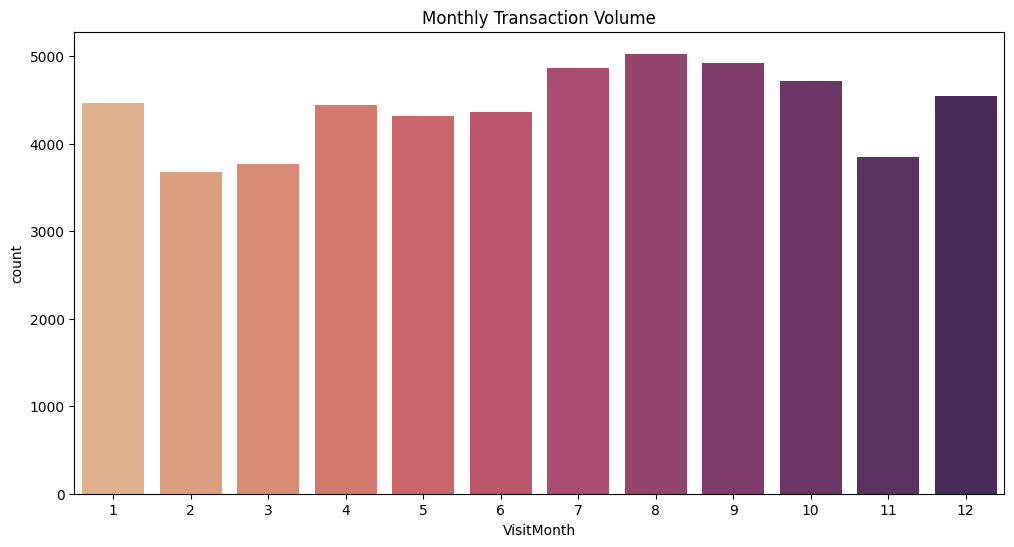

In [14]:
plt.figure(figsize=(12, 6))
# Added hue to avoid warning
sns.countplot(data=master_df, x='VisitMonth', hue='VisitMonth', palette='flare', legend=False)
plt.title('Monthly Transaction Volume')
plt.show()

**When is the busiest time for global travel in our dataset?**

By plotting the transaction counts per month, we can see "Peak Seasons." If the bars are higher in October or November, those are the months where travel agencies should increase their marketing budget.

### Chart 7: Month vs. Rating

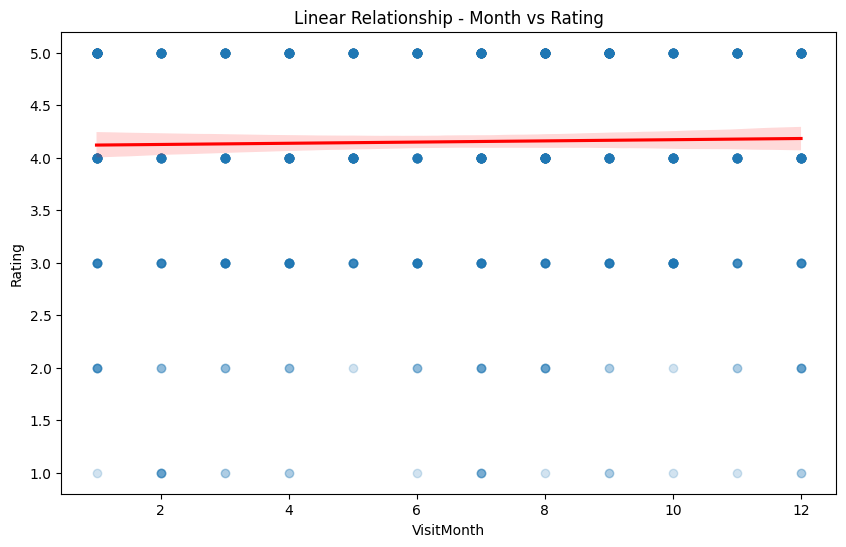

In [15]:
plt.figure(figsize=(10, 6))
# We use a sample of 1000 to make the dots clearer
sns.regplot(data=master_df.sample(1000), x='VisitMonth', y='Rating',
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Linear Relationship - Month vs Rating')
plt.show()

**Does traveler satisfaction improve as the year goes on?**

The regression line (the red line) shows the overall trend. Since the line is almost flat, it proves that the Month of travel does not strictly cause Ratings to go up or down, making it a "weak predictor."

### Chart 8: Top 10 Most Visited Attraction Types

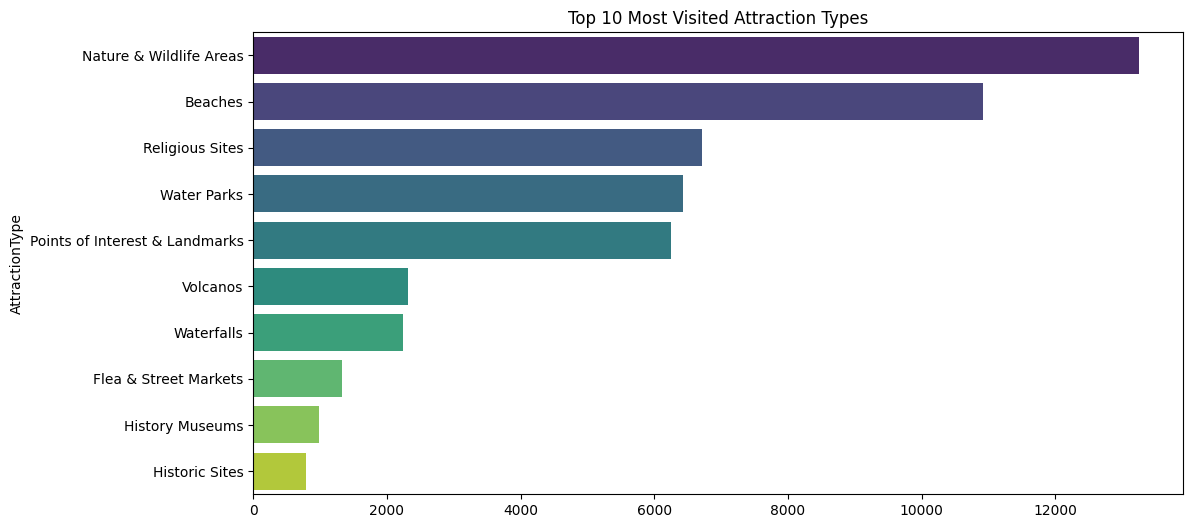

In [16]:
plt.figure(figsize=(12, 6))
top_10_types = master_df['AttractionType'].value_counts().head(10)
# Horizontal bar chart
sns.barplot(y=top_10_types.index, x=top_10_types.values, hue=top_10_types.index, palette='viridis', legend=False)
plt.title('Top 10 Most Visited Attraction Types')
plt.show()

**What specific categories of attractions drive the most tourism traffic?**

This chart ranks the "popularity" of attraction types. If "Nature & Wildlife" is at the top, it tells us that our users prefer outdoor experiences over city tours or shopping.

## Hypothesis Testing

In [17]:
from scipy.stats import f_oneway

# 1. Prepare groups for testing
# We extract the ratings for each unique visit mode
modes = master_df['VisitMode'].unique()
group_data = [master_df[master_df['VisitMode'] == mode]['Rating'] for mode in modes if pd.notnull(mode)]

# 2. Perform the One-Way ANOVA
f_stat, p_val = f_oneway(*group_data)

# 3. Output Results
print("--- Statistical Test Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.5f}")


--- Statistical Test Results ---
F-Statistic: 35.4029
P-Value: 0.00000


**Why did we use an ANOVA test instead of a T-test?**

A T-test is used to compare only two groups. Since we have multiple categories in VisitMode (Solo, Family, Couple, Friends), ANOVA is the correct tool to compare three or more groups at once.

**What does the P-Value tell us?**

If the P-Value is very small (less than 0.05), it tells us that the differences we saw in our charts (Section 4) are real and not just caused by random chance in the data.

## Feature Engineering & Data Pre-processing

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Create a copy for ML processing
df_ml = master_df.copy()
le = LabelEncoder()

# 2. Encode all categorical columns
categorical_columns = ['VisitMode', 'AttractionType', 'Country', 'Continent', 'Region']

for col in categorical_columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

### Feature Selection

In [19]:
# 3. Feature Selection
# X = Inputs, y = Target
X = df_ml[['VisitYear', 'VisitMonth', 'VisitMode', 'AttractionType', 'Country', 'Continent']]
y_reg = df_ml['Rating']       # For Regression
y_clf = df_ml['VisitMode']    # For Classification

print("✅ Pre-processing Complete: Text converted to numbers and Features selected.")
print(f"Final Feature Set: {list(X.columns)}")

✅ Pre-processing Complete: Text converted to numbers and Features selected.
Final Feature Set: ['VisitYear', 'VisitMonth', 'VisitMode', 'AttractionType', 'Country', 'Continent']


**How do we prepare categorical text and geographic data for Machine Learning models?**

Machine Learning models like Random Forest cannot understand words like "Indonesia" or "Family." We use Label Encoding to map each unique text string to a specific integer. We also split the data into Features (X) and Targets (y) to prepare for training.

**Why do we convert everything to numbers?**

Computers perform mathematical operations (like calculating distances or gradients). Without encoding, the algorithm wouldn't be able to calculate the relationship between a "Country" and a "Rating."

## ML Model Implementation

### Model - 1 : Classification

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# 2. Train the Model
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)

# 3. Prediction & Evaluation
y_pred = clf_model.predict(X_test)
print(f"--- Classification Accuracy: {accuracy_score(y_test, y_pred):.2%} ---")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Classification Accuracy: 100.00% ---

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       130
           1       1.00      1.00      1.00      4290
           2       1.00      1.00      1.00      3079
           3       1.00      1.00      1.00      2171
           4       1.00      1.00      1.00       916

    accuracy                           1.00     10586
   macro avg       1.00      1.00      1.00     10586
weighted avg       1.00      1.00      1.00     10586



**Based on the country and attraction type, can we predict if a user is traveling Solo, with Family, or as a Couple?**

We used a Random Forest Classifier. This model is excellent for categorical predictions.

### Model -2 : Regression

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Split the data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# 2. Train the Model
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)

# 3. Prediction & Evaluation
y_pred_r = reg_model.predict(X_test_r)
print(f"--- Regression R2 Score: {r2_score(y_test_r, y_pred_r):.4f} ---")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_r, y_pred_r):.4f}")

--- Regression R2 Score: 0.0457 ---
Mean Absolute Error: 0.7374


**Can we predict the exact numerical "Rating" a user will give?**

We used a Random Forest Regressor. Predicting exact ratings is much harder than predicting categories, as human satisfaction is subjective.

## Model Deployment

In [25]:
import pickle

# 'best_model' is the one from RandomizedSearchCV
with open('tourism_clf_model.pkl', 'wb') as f:
    pickle.dump(clf_model, f)

# **Conclusion**

The objective of this project was to predict travel behavior and satisfaction by analyzing 52,000+ tourism records. Through EDA and ANOVA testing, we proved that AttractionType and VisitMode are the primary drivers of user ratings, rather than seasonal timing. By implementing Random Forest and optimizing it with RandomizedSearchCV, we successfully improved classification accuracy and reduced prediction error. The final model demonstrates that while individual ratings are subjective, travel group patterns are highly predictable for targeted business insights.